## Modèle XGBoost

# Importation des bibliothèques

In [1]:
%pip install scikit-learn xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


# Chargement des données

In [2]:
df = pd.read_csv("BDD_initial/Students Social Media Addiction.csv")

print(df.shape)
print(df['Addicted_Score'].describe())
df.head()

(705, 13)
count    705.000000
mean       6.436879
std        1.587165
min        2.000000
25%        5.000000
50%        7.000000
75%        8.000000
max        9.000000
Name: Addicted_Score, dtype: float64


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [3]:
print('Types de données')
print(df.dtypes)
print('\nValeurs manquantes')
print(df.isnull().sum())
print('\nStatistiques descriptives')
df.describe()

Types de données
Student_ID                        int64
Age                               int64
Gender                           object
Academic_Level                   object
Country                          object
Avg_Daily_Usage_Hours           float64
Most_Used_Platform               object
Affects_Academic_Performance     object
Sleep_Hours_Per_Night           float64
Mental_Health_Score               int64
Relationship_Status              object
Conflicts_Over_Social_Media       int64
Addicted_Score                    int64
dtype: object

Valeurs manquantes
Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
Addicted_Score       

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
count,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000
mean,353.000000,20.659574,4.918723,6.868936,6.226950,2.849645,6.436879
std,203.660256,1.399217,1.257395,1.126848,1.105055,0.957968,1.587165
min,1.000000,18.000000,1.500000,3.800000,4.000000,0.000000,2.000000
25%,177.000000,19.000000,4.100000,6.000000,5.000000,2.000000,5.000000
50%,353.000000,21.000000,4.800000,6.900000,6.000000,3.000000,7.000000
75%,529.000000,22.000000,5.800000,7.700000,7.000000,4.000000,8.000000
max,705.000000,24.000000,8.500000,9.600000,9.000000,5.000000,9.000000


# Prétraitement des données

In [4]:
df_ml = df.copy()
df_ml = df_ml.drop(columns=['Student_ID'])

categorical_cols = df_ml.select_dtypes(include='object').columns
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    label_encoders[col] = le
    print(f'  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

df_ml.head()

  Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
  Academic_Level: {'Graduate': np.int64(0), 'High School': np.int64(1), 'Undergraduate': np.int64(2)}
  Country: {'Afghanistan': np.int64(0), 'Albania': np.int64(1), 'Andorra': np.int64(2), 'Argentina': np.int64(3), 'Armenia': np.int64(4), 'Australia': np.int64(5), 'Austria': np.int64(6), 'Azerbaijan': np.int64(7), 'Bahamas': np.int64(8), 'Bahrain': np.int64(9), 'Bangladesh': np.int64(10), 'Belarus': np.int64(11), 'Belgium': np.int64(12), 'Bhutan': np.int64(13), 'Bolivia': np.int64(14), 'Bosnia': np.int64(15), 'Brazil': np.int64(16), 'Bulgaria': np.int64(17), 'Canada': np.int64(18), 'Chile': np.int64(19), 'China': np.int64(20), 'Colombia': np.int64(21), 'Costa Rica': np.int64(22), 'Croatia': np.int64(23), 'Cyprus': np.int64(24), 'Czech Republic': np.int64(25), 'Denmark': np.int64(26), 'Ecuador': np.int64(27), 'Egypt': np.int64(28), 'Estonia': np.int64(29), 'Finland': np.int64(30), 'France': np.int64(31), 'Georgia': np.int64(32), 'G

,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,19,0,2,10,5.2,1,1,6.5,6,1,3,8
1,22,1,0,39,2.1,7,0,7.5,8,2,0,3
2,20,0,2,102,6.0,6,1,5.0,5,0,4,9
3,18,1,1,101,3.0,11,0,7.0,7,2,1,4
4,21,1,0,18,4.5,0,1,6.0,6,1,2,7


# Entrainement du modèle

In [5]:
X = df_ml.drop(columns=['Addicted_Score'])
y = df_ml['Addicted_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Ensemble d'entraînement :", X_train.shape[0], "lignes (80%)")
print("Ensemble de test        :", X_test.shape[0],  "lignes (20%)")
print("\nFeatures utilisées", len(X.columns), ":", list(X.columns))

Ensemble d'entraînement : 564 lignes (80%)
Ensemble de test        : 141 lignes (20%)

Features utilisées 11 : ['Age', 'Gender', 'Academic_Level', 'Country', 'Avg_Daily_Usage_Hours', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Relationship_Status', 'Conflicts_Over_Social_Media']


In [6]:
xgb = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

print("Modèle entraîné !")

Modèle entraîné !


# Évaluation des modèle

In [7]:
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=== Résultats — Modèle XGBoost ===")
print(f"  MAE  (erreur absolue moyenne)       : {mae:.3f}")
print(f"  RMSE (racine erreur quadratique)    : {rmse:.3f}")
print(f"  R²   (coefficient de détermination) : {r2:.3f}")
print(f"\n  Le modèle explique {r2*100:.1f}% de la variance du score")

=== Résultats — Modèle XGBoost ===
  MAE  (erreur absolue moyenne)       : 0.066
  RMSE (racine erreur quadratique)    : 0.192
  R²   (coefficient de détermination) : 0.985

  Le modèle explique 98.5% de la variance du score


# Visualisations

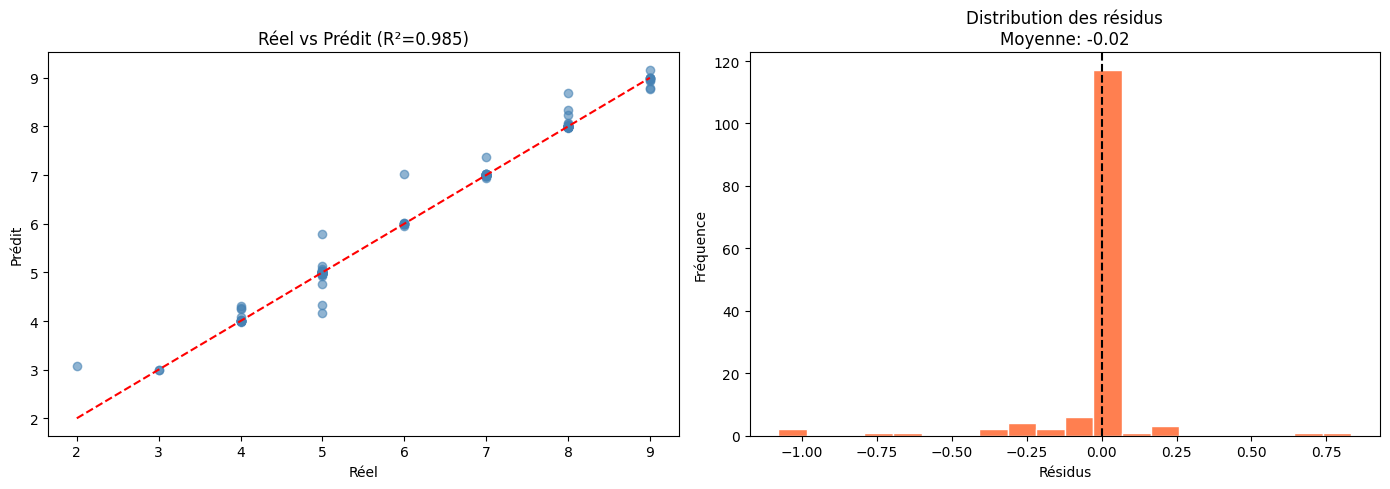

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prédictions vs Valeurs Réelles
axes[0].scatter(y_test, y_pred, alpha=0.6, color='steelblue')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
axes[0].set(xlabel='Réel', ylabel='Prédit', title=f'Réel vs Prédit (R²={r2:.3f})')

# Distribution des résidus
residus = y_test - y_pred
axes[1].hist(residus, bins=20, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set(xlabel='Résidus', ylabel='Fréquence',
            title=f'Distribution des résidus\nMoyenne: {residus.mean():.2f}')

plt.tight_layout()
plt.show()

In [9]:
cv_scores = cross_val_score(xgb, X, y, cv=5, scoring='r2')

print("=== Validation Croisée (5-fold) ===")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: R² = {score:.4f}")
print(f"\n  R² moyen   : {cv_scores.mean():.4f}")
print(f"  Écart-type : {cv_scores.std():.4f}")

=== Validation Croisée (5-fold) ===
  Fold 1: R² = 0.9214
  Fold 2: R² = 0.8853
  Fold 3: R² = 0.9923
  Fold 4: R² = 0.9873
  Fold 5: R² = 0.9352

  R² moyen   : 0.9443
  Écart-type : 0.0406


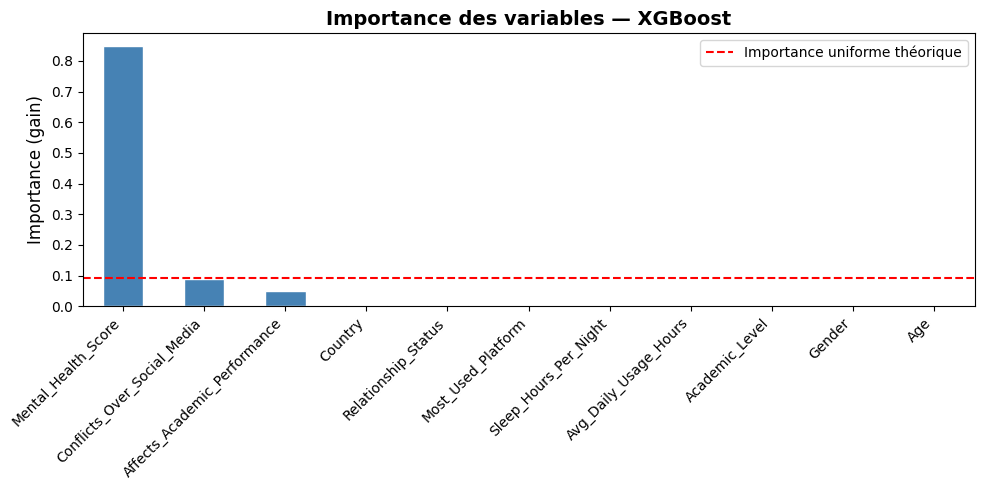

In [10]:
importances = pd.Series(
    xgb.feature_importances_, index=X.columns
).sort_values(ascending=False)

importances.plot(kind='bar', figsize=(10, 5), color='steelblue', edgecolor='white')
plt.ylabel('Importance (gain)', fontsize=12)
plt.title('Importance des variables — XGBoost', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.axhline(
    y=1 / len(X.columns), color='red', linestyle='--',
    label='Importance uniforme théorique'
)
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
param_grid = {
    'n_estimators' : [50, 100, 200],
    'max_depth'    : [None, 5, 10, 20],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample'    : [0.8, 1.0, None]
}

grid_search = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid, cv=5, scoring='r2', n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)

comparaison = pd.DataFrame({
    'Base'    : {'R²' : round(r2, 3), 'MAE': round(mae, 3)},
    'Optimisé': {
        'R²' : round(r2_score(y_test, y_pred_best), 3),
        'MAE': round(mean_absolute_error(y_test, y_pred_best), 3)
    }
})
comparaison['Δ'] = comparaison['Optimisé'] - comparaison['Base']
print(f"Meilleurs paramètres : {grid_search.best_params_}")
display(comparaison)

Meilleurs paramètres : {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


,Base,Optimisé,Δ
R²,0.985,0.979,-0.006
MAE,0.066,0.087,0.021
